# Data Preparation Pipeline

Complete data preparation pipeline for RL portfolio rebalancing:
1. Data acquisition from Yahoo Finance
2. Feature engineering (momentum, volatility, volume, risk-adjusted metrics, etc.)
3. Data preprocessing (outlier removal, correlation filtering, normalization)
4. Train/test split (80/20)
5. Save processed data


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json

project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

from utile import (
    fetch_price_data, prepare_price_dataframe, fetch_macro_data,
    engineer_all_features, preprocess_pipeline, fetch_benchmark_returns
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Configuration

Define assets, date range, and directories.


In [2]:
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'NFLX']
START_DATE = '2020-01-01'
END_DATE = '2025-01-01'
INTERVAL = '1wk'

DATA_DIR = project_root / 'data'
RAW_DATA_DIR = DATA_DIR / 'raw'
PROCESSED_DATA_DIR = DATA_DIR / 'processed'
RESULTS_DIR = project_root / 'results'

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


## Step 1: Fetch Price Data

Download weekly price data from Yahoo Finance.


In [3]:
price_data = fetch_price_data(
    tickers=TICKERS,
    start_date=START_DATE,
    end_date=END_DATE,
    interval=INTERVAL
)

price_df = prepare_price_dataframe(price_data)
price_df = price_df.sort_values(['date', 'ticker']).reset_index(drop=True)

price_df.to_parquet(RAW_DATA_DIR / 'weekly_prices.parquet', index=False)


### Data Overview

Visualize price data to verify quality and coverage.


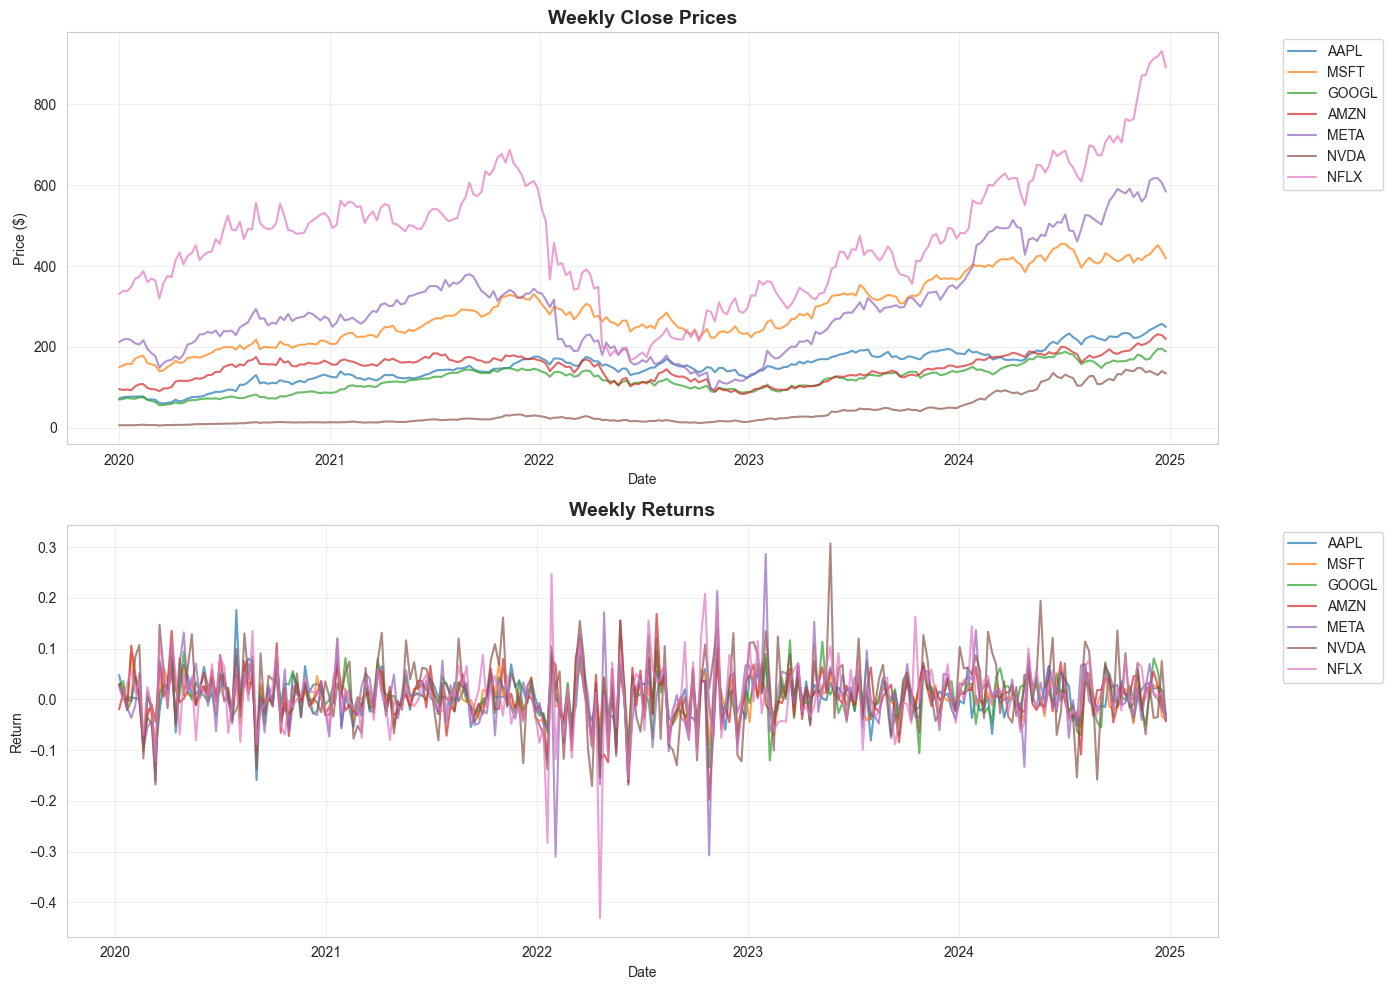

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ticker in TICKERS:
    ticker_data = price_df[price_df['ticker'] == ticker]
    axes[0].plot(ticker_data['date'], ticker_data['close'], label=ticker, alpha=0.7)

axes[0].set_title('Weekly Close Prices', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price ($)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

for ticker in TICKERS:
    ticker_data = price_df[price_df['ticker'] == ticker]
    returns = ticker_data['close'].pct_change()
    axes[1].plot(ticker_data['date'], returns, label=ticker, alpha=0.7)

axes[1].set_title('Weekly Returns', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Return')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'price_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 2: Feature Engineering

Calculate comprehensive features across all categories.


In [5]:
# Fetch benchmark returns using the helper function
benchmark_returns = fetch_benchmark_returns(
    ticker='QQQ',
    start_date=START_DATE,
    end_date=END_DATE,
    interval=INTERVAL
)

# Fetch macroeconomic data from FRED
macro_data = fetch_macro_data(
    start_date=START_DATE,
    end_date=END_DATE
)

features_df = engineer_all_features(
    price_df, 
    benchmark_returns=benchmark_returns,
    macro_data=macro_data
)

feature_cols = [col for col in features_df.columns 
                if col not in ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume']]

features_df.to_parquet(RAW_DATA_DIR / 'features_raw.parquet', index=False)

features_df


,date,open,high,low,close,volume,ticker,treasury_10y,fed_funds_rate,vix,...,kurt_13w,kurt_26w,autocorr_1w,autocorr_4w,sin_month,cos_month,sin_dow,cos_dow,sin_dom,cos_dom
0,2020-01-01,74.059998,75.224998,73.187500,71.995361,509062400,AAPL,1.87,1.55,13.45,...,NaN,NaN,NaN,NaN,5.000000e-01,0.866025,0.974928,-0.222521,0.201299,0.979530
1,2020-01-01,93.750000,95.694504,93.000000,95.343002,318002000,AMZN,1.87,1.55,13.45,...,NaN,NaN,NaN,NaN,5.000000e-01,0.866025,0.974928,-0.222521,0.201299,0.979530
2,2020-01-01,67.420502,70.175003,67.324501,69.277687,131784000,GOOGL,1.87,1.55,13.45,...,NaN,NaN,NaN,NaN,5.000000e-01,0.866025,0.974928,-0.222521,0.201299,0.979530
3,2020-01-01,206.750000,214.580002,206.270004,211.754578,55236800,META,1.87,1.55,13.45,...,NaN,NaN,NaN,NaN,5.000000e-01,0.866025,0.974928,-0.222521,0.201299,0.979530
4,2020-01-01,158.779999,160.729996,156.509995,149.899307,86186100,MSFT,1.87,1.55,13.45,...,NaN,NaN,NaN,NaN,5.000000e-01,0.866025,0.974928,-0.222521,0.201299,0.979530
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1822,2024-12-25,195.149994,196.750000,188.509995,188.684860,62669600,GOOGL,4.50,5.33,27.62,...,-0.437811,-0.603851,0.140648,0.124977,-2.449294e-16,1.000000,0.974928,-0.222521,-0.937752,0.347305
1823,2024-12-25,605.479980,606.299988,583.849976,584.145508,27211000,META,4.50,5.33,27.62,...,0.172597,-0.433918,-0.075354,-0.464017,-2.449294e-16,1.000000,0.974928,-0.222521,-0.937752,0.347305
1824,2024-12-25,439.079987,440.940002,420.660004,419.196564,52717100,MSFT,4.50,5.33,27.62,...,-0.962707,-0.858665,-0.068857,0.146566,-2.449294e-16,1.000000,0.974928,-0.222521,-0.937752,0.347305
1825,2024-12-25,928.400024,930.489990,889.469971,891.320007,9645400,NFLX,4.50,5.33,27.62,...,-0.243494,-0.768218,-0.218356,-0.004175,-2.449294e-16,1.000000,0.974928,-0.222521,-0.937752,0.347305


## Step 3: Data Preprocessing

Apply preprocessing pipeline: outlier removal, correlation filtering, split, normalization.


In [6]:
# Check data before cleaning
print(f"Rows before cleaning: {len(features_df)}")
print(f"Feature columns: {len(feature_cols)}")

# Check missing data pattern
missing_counts = features_df[feature_cols].isna().sum()
high_missing_features = missing_counts[missing_counts / len(features_df) > 0.5]
if len(high_missing_features) > 0:
    print(f"Features with >50% missing: {len(high_missing_features)}")
    print(high_missing_features.head(10))

# Drop rows only if more than 50% of features are missing (less aggressive)
row_missing_pct = features_df[feature_cols].isna().sum(axis=1) / len(feature_cols)
features_df_clean = features_df[row_missing_pct <= 0.5].copy()
print(f"Rows after cleaning (dropped rows with >50% missing features): {len(features_df_clean)}")

if len(features_df_clean) == 0:
    raise ValueError("All rows dropped after cleaning. Check for features with too many missing values.")

preprocessed = preprocess_pipeline(
    df=features_df_clean,
    feature_cols=feature_cols,
    train_ratio=0.8,
    clip_percentiles=(0.01, 0.99),
    corr_threshold=0.9,
    use_pca=False,
    date_col='date'
)

train_df = preprocessed['train']
test_df = preprocessed['test']
scaler = preprocessed['scaler']
removed_features = preprocessed['removed_features']


Rows before cleaning: 1827
Feature columns: 160
Features with >50% missing: 5
volatility_ratio_4w    1169
avg_drawdown_4w        1437
avg_drawdown_13w       1511
avg_drawdown_26w       1511
avg_drawdown_52w       1622
dtype: int64
Rows after cleaning (dropped rows with >50% missing features): 1736


/Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/utile.py:790: UserWarning: Removed 2 constant features: ['sin_dow', 'cos_dow']
  warnings.warn(f"Removed {len(constant_features)} constant features: {constant_features}", UserWarning)


### Preprocessing Summary

Display statistics about preprocessing steps.


In [7]:
final_feature_cols = [col for col in train_df.columns 
                      if col not in ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume']]

summary = {
    'Original Features': len(feature_cols),
    'Removed (High Correlation)': len(removed_features),
    'Final Features': len(final_feature_cols),
    'Train Samples': len(train_df),
    'Test Samples': len(test_df),
    'Train Dates': train_df['date'].nunique(),
    'Test Dates': test_df['date'].nunique()
}

summary_df = pd.DataFrame([summary]).T
summary_df.columns = ['Value']
print(summary_df.to_string())


                            Value
Original Features             160
Removed (High Correlation)     50
Final Features                110
Train Samples                1386
Test Samples                  350
Train Dates                   198
Test Dates                     50


### Feature Distribution After Normalization

Visualize normalized feature distributions.


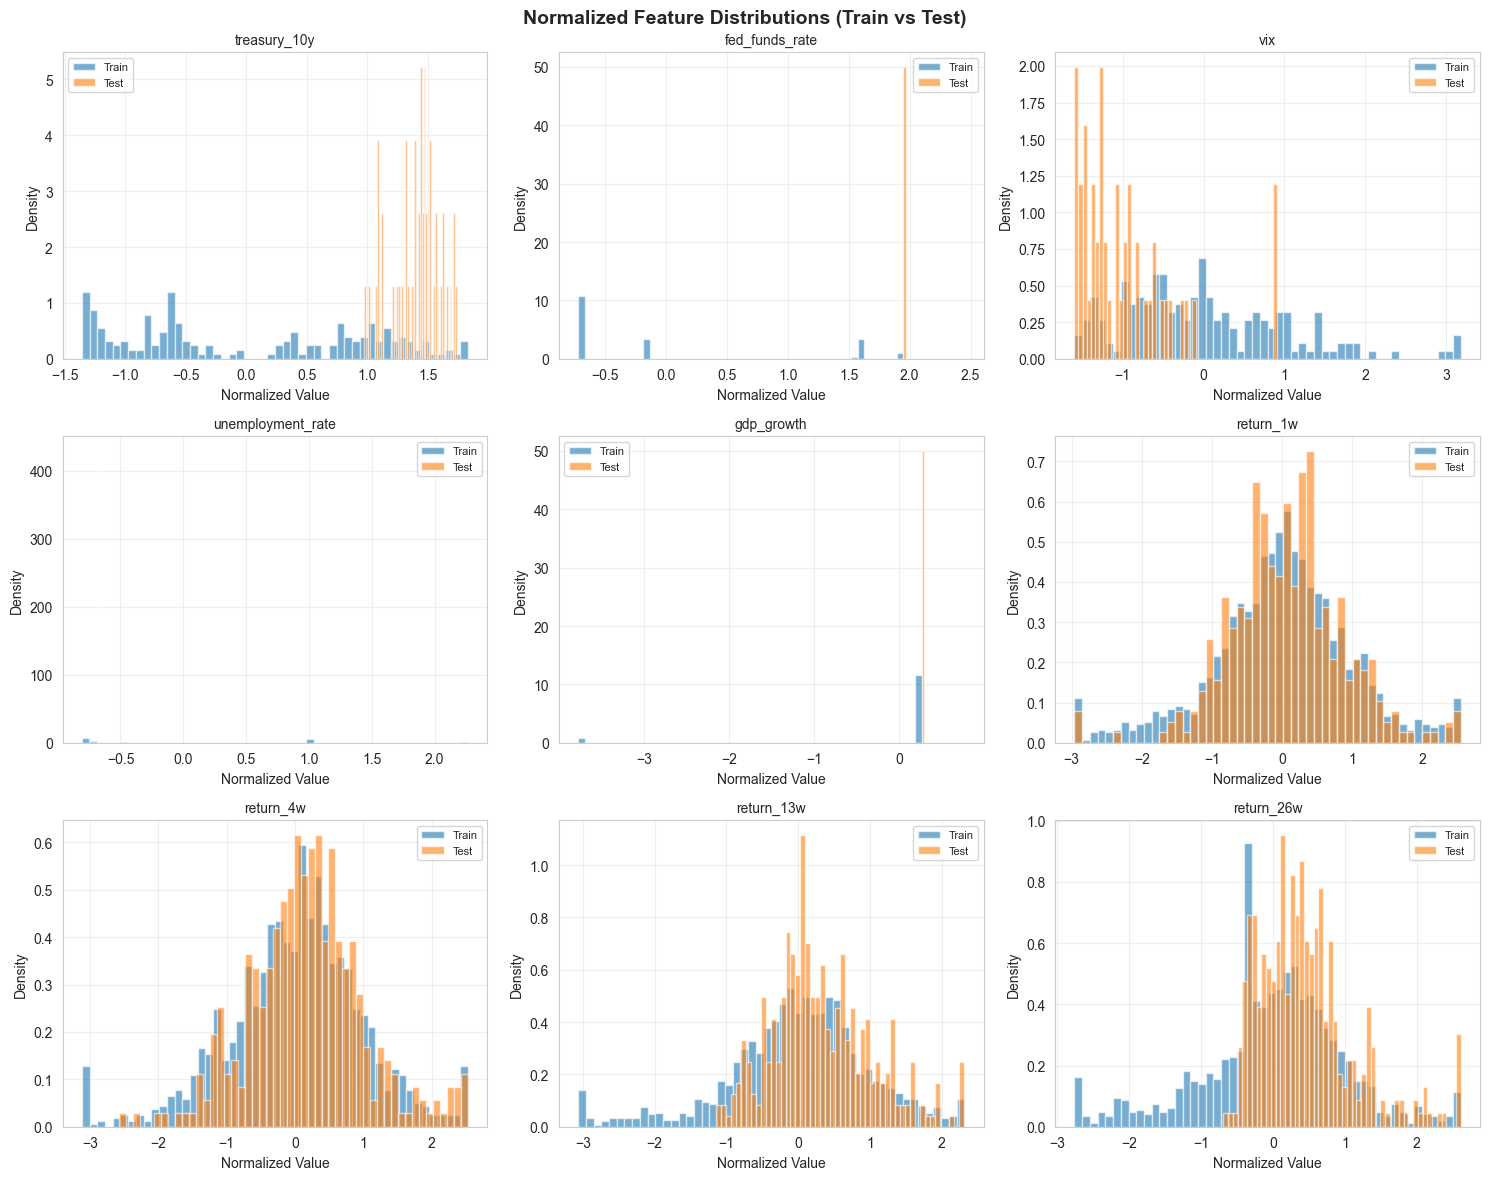

In [8]:
sample_features = final_feature_cols[:9]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, feat in enumerate(sample_features):
    if feat in train_df.columns:
        train_vals = train_df[feat].dropna()
        test_vals = test_df[feat].dropna()
        
        axes[idx].hist(train_vals, bins=50, alpha=0.6, label='Train', density=True)
        axes[idx].hist(test_vals, bins=50, alpha=0.6, label='Test', density=True)
        axes[idx].set_title(feat, fontsize=10)
        axes[idx].set_xlabel('Normalized Value')
        axes[idx].set_ylabel('Density')
        axes[idx].legend(fontsize=8)
        axes[idx].grid(True, alpha=0.3)

plt.suptitle('Normalized Feature Distributions (Train vs Test)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


### Feature Correlation Matrix

Visualize correlation matrix of final features, sorted by hierarchical clustering to group correlated features together.


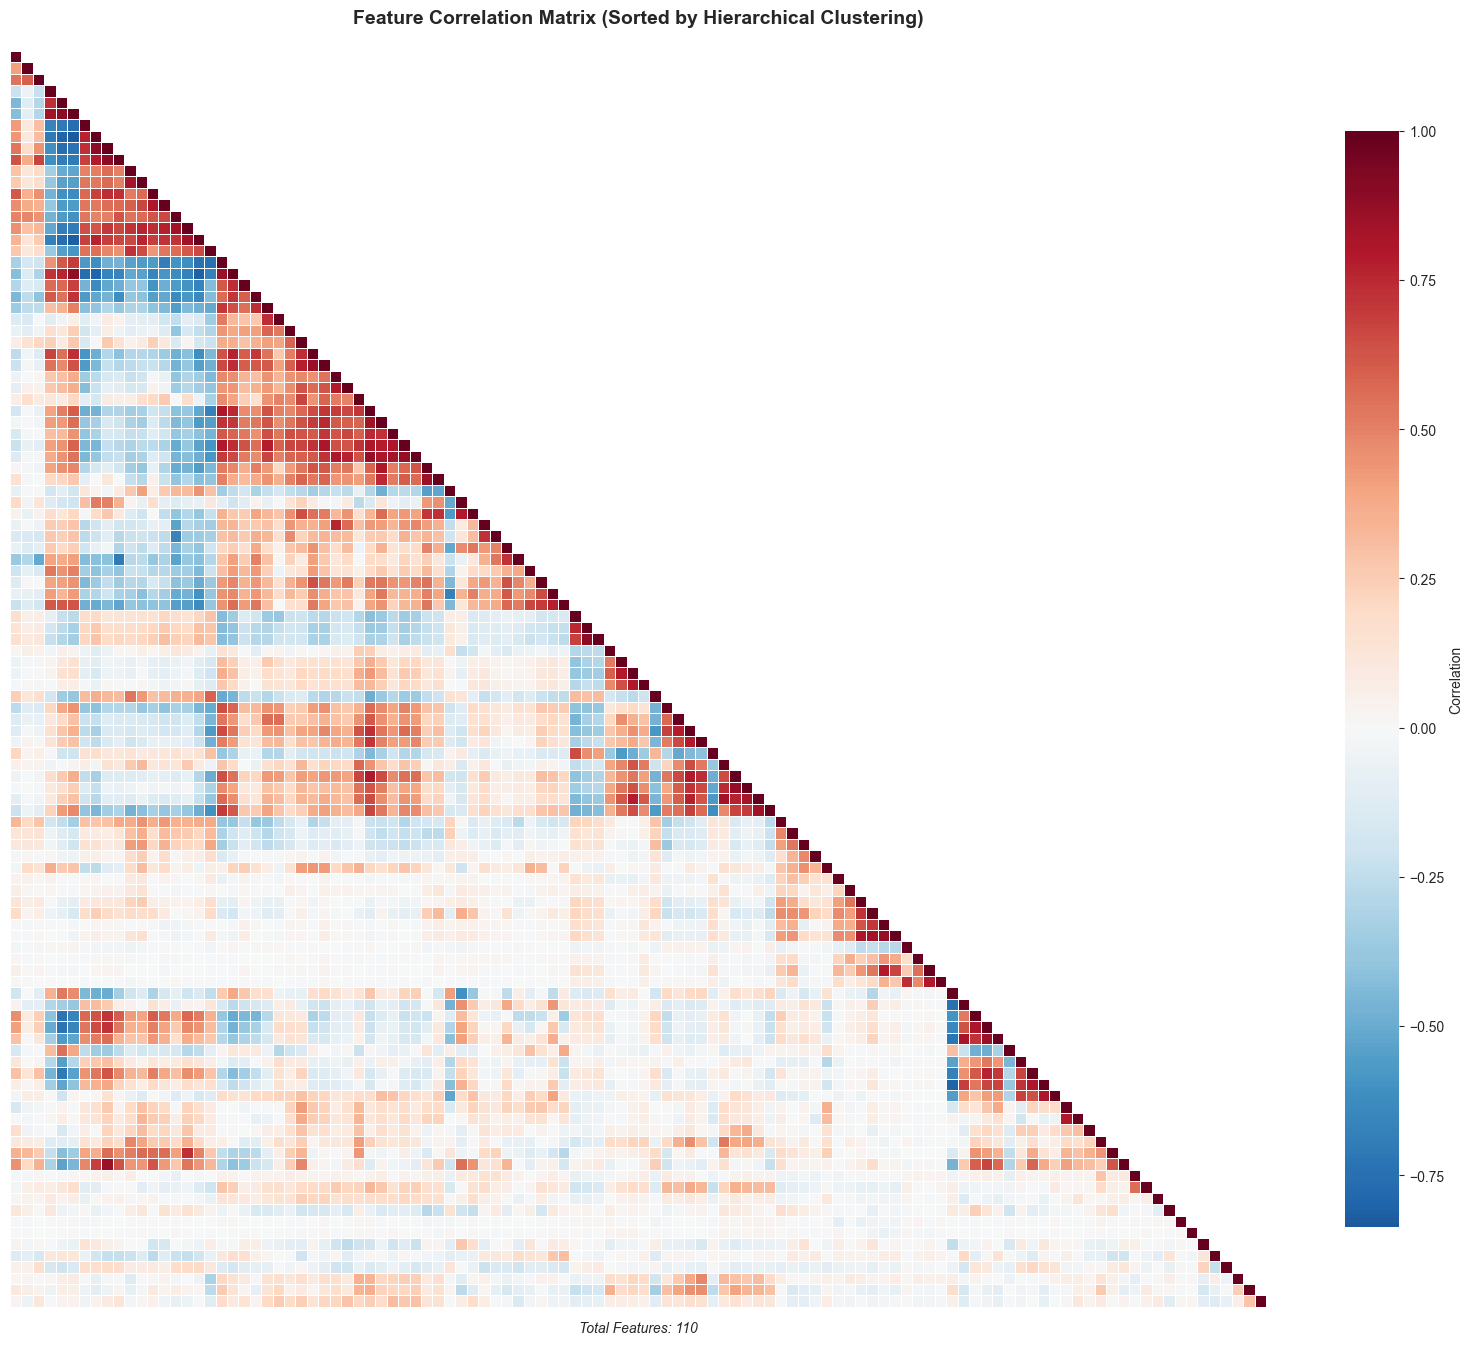


Correlation Statistics:
  Mean absolute correlation: 0.1978
  Max correlation: 0.8907
  Min correlation: -0.8366
  Features with |correlation| > 0.7: 286 pairs
  Features with |correlation| > 0.9: 0 pairs


In [9]:
# Calculate correlation matrix using training data
corr_data = train_df[final_feature_cols].fillna(0)
corr_matrix = corr_data.corr()

# Use hierarchical clustering to sort features by correlation similarity
# This groups highly correlated features together
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# Convert correlation to distance (1 - abs(correlation))
dist_matrix = 1 - np.abs(corr_matrix.values)
np.fill_diagonal(dist_matrix, 0)

# Perform hierarchical clustering
condensed_dist = squareform(dist_matrix)
linkage_matrix = linkage(condensed_dist, method='ward')

# Get the order of features from dendrogram
from scipy.cluster.hierarchy import leaves_list
ordered_indices = leaves_list(linkage_matrix)
ordered_features = [final_feature_cols[i] for i in ordered_indices]

# Reorder correlation matrix
corr_matrix_sorted = corr_matrix.loc[ordered_features, ordered_features]

# Create heatmap
fig, ax = plt.subplots(figsize=(16, 14))

# Use a diverging colormap centered at 0
mask = np.triu(np.ones_like(corr_matrix_sorted, dtype=bool), k=1)  # Mask upper triangle

sns.heatmap(
    corr_matrix_sorted,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    xticklabels=False,  # Hide labels for readability (too many features)
    yticklabels=False,
    ax=ax
)

ax.set_title('Feature Correlation Matrix (Sorted by Hierarchical Clustering)', 
             fontsize=14, fontweight='bold', pad=20)

# Add text annotation with number of features
ax.text(0.5, -0.02, f'Total Features: {len(final_feature_cols)}', 
        transform=ax.transAxes, ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\nCorrelation Statistics:")
print(f"  Mean absolute correlation: {np.abs(corr_matrix_sorted.values).mean():.4f}")
print(f"  Max correlation: {corr_matrix_sorted.values[np.triu_indices_from(corr_matrix_sorted.values, k=1)].max():.4f}")
print(f"  Min correlation: {corr_matrix_sorted.values[np.triu_indices_from(corr_matrix_sorted.values, k=1)].min():.4f}")
print(f"  Features with |correlation| > 0.7: {(np.abs(corr_matrix_sorted.values) > 0.7).sum() - len(final_feature_cols)} pairs")
print(f"  Features with |correlation| > 0.9: {(np.abs(corr_matrix_sorted.values) > 0.9).sum() - len(final_feature_cols)} pairs")


## Step 4: Save Processed Data

Save preprocessed datasets and metadata for RL environment and training.


In [10]:
train_df.to_parquet(PROCESSED_DATA_DIR / 'train.parquet', index=False)
test_df.to_parquet(PROCESSED_DATA_DIR / 'test.parquet', index=False)

with open(PROCESSED_DATA_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

metadata = {
    'feature_cols': final_feature_cols,
    'removed_features': removed_features,
    'train_start': train_df['date'].min().isoformat(),
    'train_end': train_df['date'].max().isoformat(),
    'test_start': test_df['date'].min().isoformat(),
    'test_end': test_df['date'].max().isoformat(),
    'n_tickers': train_df['ticker'].nunique(),
    'tickers': sorted(train_df['ticker'].unique().tolist())
}

with open(PROCESSED_DATA_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)


## Summary

Data preparation pipeline completed successfully. Processed datasets are ready for RL environment and agent training.

**Key outputs:**
- Raw price data: `data/raw/weekly_prices.parquet`
- Raw features: `data/raw/features_raw.parquet`
- Processed train set: `data/processed/train.parquet`
- Processed test set: `data/processed/test.parquet`
- Scaler: `data/processed/scaler.pkl`
- Metadata: `data/processed/metadata.json`
